## Python & ML Foundation Assignment: Iris Dataset Analysis

### Import Libraries

In [33]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Load the Iris Dataset

In [34]:
# Load the dataset from scikit-learn
df = pd.read_csv("Iris.csv")
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [35]:
df.shape

(150, 6)

### Dataset Overview
- The Iris dataset includes input features (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) and the target column Species, with values Iris-setosa, Iris-versicolor, and Iris-virginica. The Id column is unnecessary for analysis and can be removed.

### Clean the Dataset

In [36]:
# Drop 'ID' columns
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("Dropped Id column.")

# Rename columns
df.columns = ['sepal length (cm)','sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

print("\nUpdated Datseet shape:", df.shape)
df.head(5)

Dropped Id column.

Updated Datseet shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


####  
- Now, The dataset is loaded with 150 rows and 5 columns (4 features + species). 

### 2. Pandas Exploration

In [37]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [38]:
# Check for misiing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [39]:
# Unique species and counts
print(df['species'].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [40]:
# Group by species and calcualte the mean values
df.groupby('species').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [41]:
## Correlation matrix for numerical features
df.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.109369,0.871754,0.817954
sepal width (cm),-0.109369,1.000000,-0.420516,-0.356544
petal length (cm),0.871754,-0.420516,1.000000,0.962757
petal width (cm),0.817954,-0.356544,0.962757,1.000000


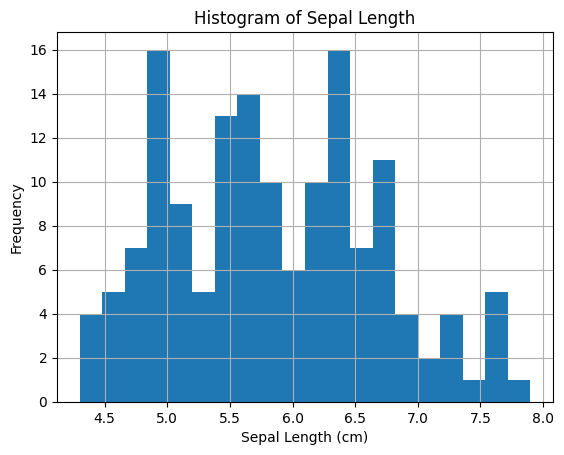

In [42]:
# Histogram for one features
df['sepal length (cm)'].hist(bins=20)
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.show()

### Exploration Insights:
- **No missing values** ensure data quality.
- **Balanced classes** (50 samples per species).
- **Correlations**: Petal length and width are strongly correlated (~0.96), useful for classification.
- **Distributions**: Histograms suggest multimodal patterns due to species differences.

###  3. Summary of the Dataset
- This section provides stastical summaries and visulizations to hightlight the key characterisitics of the Iris dataset

In [43]:
# Descriptive statistics for numerical features
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.054000           3.758667   
std             0.828066          0.433594           1.764420   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.198667  
std            0.763161  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [44]:
# Deescriptives statistics by specis(target)
print(df.groupby('species').describe())

                sepal length (cm)                                              \
                            count   mean       std  min    25%  50%  75%  max   
species                                                                         
Iris-setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
Iris-versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
Iris-virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

                sepal width (cm)         ... petal length (cm)       \
                           count   mean  ...               75%  max   
species                                  ...                          
Iris-setosa                 50.0  3.418  ...             1.575  1.9   
Iris-versicolor             50.0  2.770  ...             4.600  5.1   
Iris-virginica              50.0  2.974  ...             5.875  6.9   

                petal width (cm)                                            
         

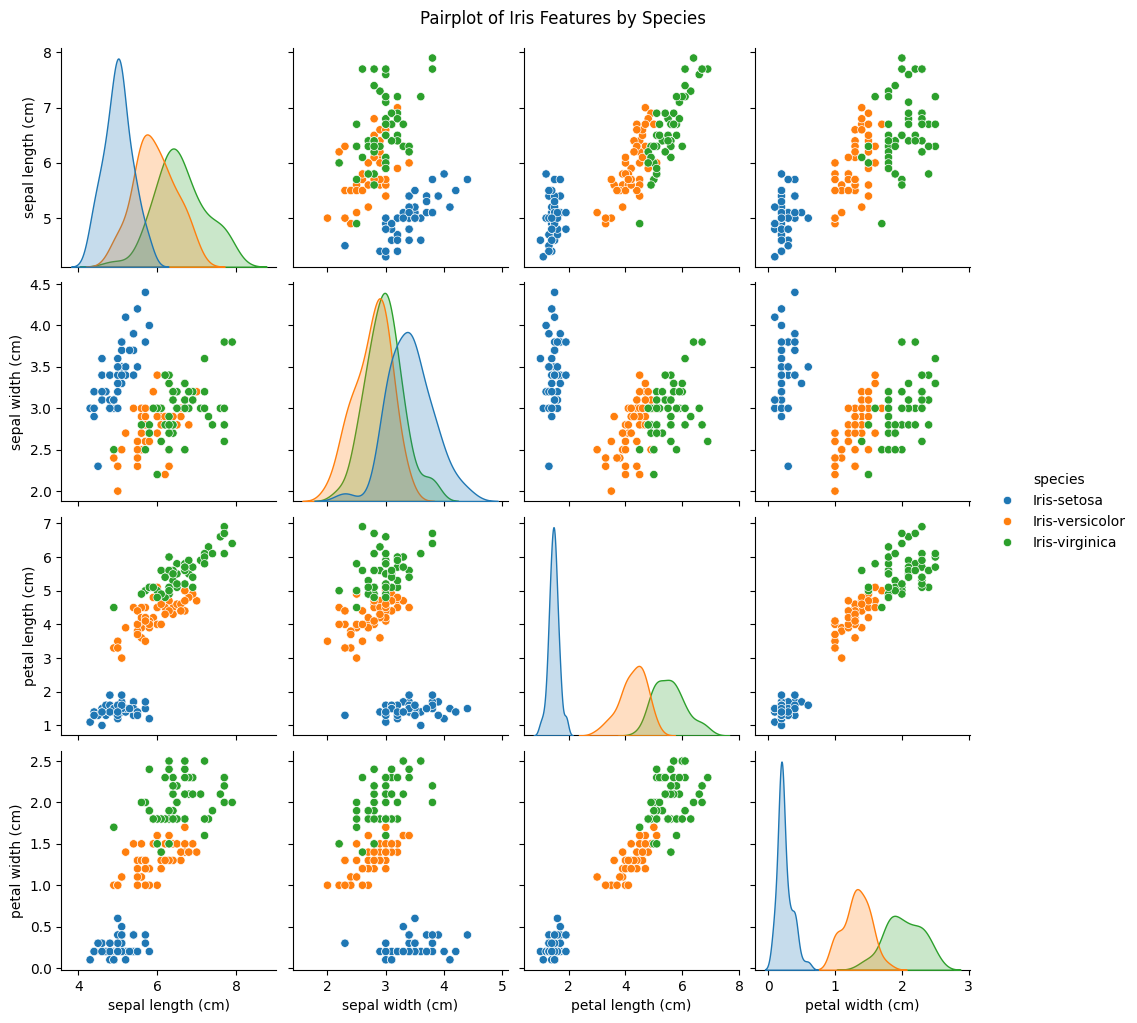

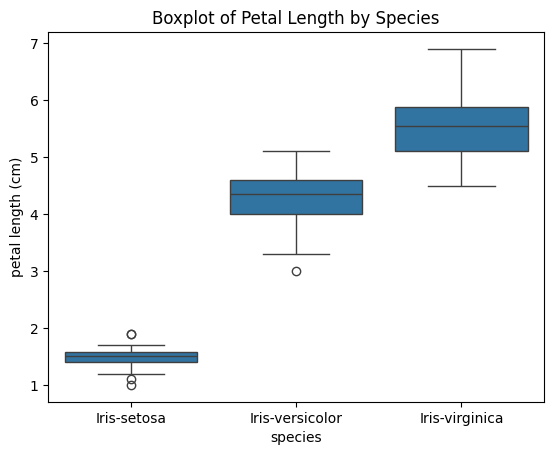

In [45]:
# Pairplot to visualize relationships
sns.pairplot(df, hue='species')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# Boxplot for petal length by species
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Boxplot of Petal Length by Species')
plt.show()

### Summary Insights:
- **Statistics**: Features range from ~0.1-7.9 cm; sepal width has lowest variance.
- **Species Differences**: Setosa has smallest petals, Virginica largest; Versicolor intermediate.
- **Visualizations**: Pairplot shows clear separation for Setosa; boxplots confirm minimal outliers.
- **Conclusion**: The dataset is clean, balanced, and ideal for machine learning tasks like classification.
